In [5]:
from pathlib import Path
import sys
import json
import re
import time
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore", category=FutureWarning)


# Detect project root
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data_preprocessing import build_preprocessor


RANDOM_STATE = 42
TARGET = "Diabetes_binary"
EXPERIMENT_NAME = "diabetes-risk-advanced-models"

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "diabetes_no_duplicates.csv"
)

BASELINE_RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "baseline_model_results.csv"
)

ADVANCED_RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "advanced_model_results.csv"
)

ALL_RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "all_model_comparison.csv"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "day4"
)

MLRUNS_DIR = PROJECT_ROOT / "mlruns"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MLRUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("MLflow directory:", MLRUNS_DIR)

Project root: /Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops
Dataset path: /Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/data/processed/diabetes_no_duplicates.csv
MLflow directory: /Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/mlruns


In [6]:
import sklearn
import xgboost
import lightgbm
import catboost

print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)
print("CatBoost:", catboost.__version__)
print("MLflow:", mlflow.__version__)

Scikit-learn: 1.9.0
XGBoost: 3.3.0
LightGBM: 4.6.0
CatBoost: 1.2.10
MLflow: 3.14.0


In [7]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' is missing."
    )

# Convert target to integer labels: 0 and 1
df[TARGET] = df[TARGET].astype(int)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df[TARGET].value_counts())

print("\nTarget percentages:")
print(df[TARGET].value_counts(normalize=True).mul(100).round(2))

df.head()

Dataset shape: (229474, 22)

Target distribution:
Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64

Target percentages:
Diabetes_binary
0    84.71
1    15.29
Name: proportion, dtype: float64


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [11]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

X_train shape: (183579, 21)
X_test shape: (45895, 21)
y_train shape: (183579,)
y_test shape: (45895,)

Training target distribution:
Diabetes_binary
0    155501
1     28078
Name: count, dtype: int64


Gradient Boosting → balanced sample weights \
XGBoost → scale_pos_weight \
LightGBM → scale_pos_weight \
CatBoost → auto_class_weights="Balanced"

In [9]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

if positive_count == 0:
    raise ValueError(
        "Training data contains no positive-class samples."
    )

scale_pos_weight = negative_count / positive_count

gradient_boosting_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Negative-class samples:", negative_count)
print("Positive-class samples:", positive_count)
print("Scale positive weight:", round(scale_pos_weight, 4))
print("Sample weights shape:", gradient_boosting_weights.shape)

Negative-class samples: 155501
Positive-class samples: 28078
Scale positive weight: 5.5382
Sample weights shape: (183579,)


In [12]:
MLFLOW_DB_PATH = PROJECT_ROOT / "mlflow.db"

tracking_uri = f"sqlite:///{MLFLOW_DB_PATH.resolve().as_posix()}"

mlflow.set_tracking_uri(tracking_uri)

experiment = mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)



2026/07/12 12:22:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/12 12:22:03 INFO mlflow.store.db.utils: Updating database tables
2026/07/12 12:22:03 INFO mlflow.tracking.fluent: Experiment with name 'diabetes-risk-advanced-models' does not exist. Creating a new experiment.


Tracking URI: sqlite:////Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/mlflow.db
Experiment name: diabetes-risk-advanced-models
Experiment ID: 1


In [13]:
def slugify(value):
    """
    Convert a model name into a safe filename.

    Example:
    'Gradient Boosting' -> 'gradient_boosting'
    """
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        value.lower()
    ).strip("_")


def calculate_metrics(y_true, y_pred, y_proba):
    """
    Calculate evaluation metrics for the positive class.
    """

    return {
        "accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "f1_score": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "roc_auc": float(
            roc_auc_score(y_true, y_proba)
        )
    }


def save_evaluation_artifacts(
    model_name,
    y_true,
    y_pred,
    metrics
):
    """
    Save the confusion matrix, classification report
    and metrics for one model.
    """

    model_slug = slugify(model_name)

    confusion_matrix_path = (
        FIGURES_DIR
        / f"{model_slug}_confusion_matrix.png"
    )

    classification_report_path = (
        FIGURES_DIR
        / f"{model_slug}_classification_report.json"
    )

    metrics_path = (
        FIGURES_DIR
        / f"{model_slug}_metrics.json"
    )

    # Confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Non-Diabetic",
            "Diabetic"
        ]
    )

    display.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        f"{model_name} - Confusion Matrix"
    )

    fig.tight_layout()

    fig.savefig(
        confusion_matrix_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=[
            "Non-Diabetic",
            "Diabetic"
        ],
        output_dict=True,
        zero_division=0
    )

    with open(
        classification_report_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(report, file, indent=2)

    # Metrics JSON
    with open(
        metrics_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(metrics, file, indent=2)

    return (
        confusion_matrix_path,
        classification_report_path,
        metrics_path
    )

In [14]:
MODEL_CONFIGS = {
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.80,
            random_state=RANDOM_STATE
        ),

        "fit_params": {
            "model__sample_weight": gradient_boosting_weights
        },

        "log_params": {
            "n_estimators": 150,
            "learning_rate": 0.05,
            "max_depth": 3,
            "subsample": 0.80,
            "random_state": RANDOM_STATE,
            "imbalance_strategy": "balanced_sample_weight"
        }
    },

    "XGBoost": {
        "model": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=1,
            subsample=0.80,
            colsample_bytree=0.80,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "fit_params": {},

        "log_params": {
            "n_estimators": 300,
            "learning_rate": 0.05,
            "max_depth": 5,
            "min_child_weight": 1,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "reg_lambda": 1.0,
            "scale_pos_weight": scale_pos_weight,
            "tree_method": "hist",
            "random_state": RANDOM_STATE
        }
    },

    "LightGBM": {
        "model": LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            subsample=0.80,
            subsample_freq=1,
            colsample_bytree=0.80,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        ),

        "fit_params": {},

        "log_params": {
            "n_estimators": 300,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.80,
            "subsample_freq": 1,
            "colsample_bytree": 0.80,
            "reg_lambda": 1.0,
            "scale_pos_weight": scale_pos_weight,
            "random_state": RANDOM_STATE
        }
    },

    "CatBoost": {
        "model": CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=0,
            allow_writing_files=False,
            thread_count=-1
        ),

        "fit_params": {},

        "log_params": {
            "iterations": 300,
            "learning_rate": 0.05,
            "depth": 6,
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "auto_class_weights": "Balanced",
            "random_seed": RANDOM_STATE
        }
    }
}

print("Models configured:")

for model_name in MODEL_CONFIGS:
    print("-", model_name)

Models configured:
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost


In [16]:
# Reset results before running all models again
results = []

# Close any MLflow run left active by a previous error
if mlflow.active_run() is not None:
    mlflow.end_run()


for model_name, config in MODEL_CONFIGS.items():

    print("\n" + "=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    # Create a fresh preprocessor for every model
    preprocessor = build_preprocessor()

    # Complete preprocessing + model pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", config["model"])
        ]
    )

    with mlflow.start_run(
        run_name=model_name
    ) as run:

        # -------------------------------------------------
        # 1. Log MLflow tags
        # -------------------------------------------------
        mlflow.set_tags({
            "project": "diabetes-risk-prediction",
            "stage": "advanced-model-training",
            "dataset": "BRFSS-2015",
            "model_name": model_name
        })

        # -------------------------------------------------
        # 2. Log model parameters
        # -------------------------------------------------
        mlflow.log_params(
            config["log_params"]
        )

        mlflow.log_params({
            "train_rows": len(X_train),
            "test_rows": len(X_test),
            "feature_count": X_train.shape[1],
            "test_size": 0.20,
            "positive_class_threshold": 0.50,
            "random_state": RANDOM_STATE
        })

        # -------------------------------------------------
        # 3. Train the pipeline
        # -------------------------------------------------
        start_time = time.perf_counter()

        pipeline.fit(
            X_train,
            y_train,
            **config["fit_params"]
        )

        training_time = (
            time.perf_counter() - start_time
        )

        # -------------------------------------------------
        # 4. Generate predictions
        # -------------------------------------------------
        y_pred = pipeline.predict(X_test)

        y_proba = pipeline.predict_proba(
            X_test
        )[:, 1]

        # -------------------------------------------------
        # 5. Calculate and log metrics
        # -------------------------------------------------
        metrics = calculate_metrics(
            y_true=y_test,
            y_pred=y_pred,
            y_proba=y_proba
        )

        metrics["training_time_seconds"] = float(
            training_time
        )

        mlflow.log_metrics(metrics)

        # -------------------------------------------------
        # 6. Save evaluation artifacts locally
        # -------------------------------------------------
        (
            confusion_matrix_path,
            classification_report_path,
            metrics_path
        ) = save_evaluation_artifacts(
            model_name=model_name,
            y_true=y_test,
            y_pred=y_pred,
            metrics=metrics
        )

        # -------------------------------------------------
        # 7. Log evaluation artifacts to MLflow
        # -------------------------------------------------
        mlflow.log_artifact(
            str(confusion_matrix_path),
            artifact_path="evaluation"
        )

        mlflow.log_artifact(
            str(classification_report_path),
            artifact_path="evaluation"
        )

        mlflow.log_artifact(
            str(metrics_path),
            artifact_path="evaluation"
        )

        # -------------------------------------------------
        # 8. Create model signature and input example
        # -------------------------------------------------
        input_example = X_test.head(5).copy()

        example_predictions = pipeline.predict(
            input_example
        )

        signature = infer_signature(
            model_input=input_example,
            model_output=example_predictions
        )

        # -------------------------------------------------
        # 9. Log the complete pipeline
        #
        # cloudpickle fixes the untrusted-type error for
        # XGBoost, LightGBM and CatBoost estimators.
        # -------------------------------------------------
        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            input_example=input_example,
            serialization_format="cloudpickle"
        )

        # -------------------------------------------------
        # 10. Store result for the comparison DataFrame
        # -------------------------------------------------
        model_result = {
            "model": model_name,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1_score": metrics["f1_score"],
            "roc_auc": metrics["roc_auc"],
            "training_time_seconds": metrics[
                "training_time_seconds"
            ],
            "mlflow_run_id": run.info.run_id
        }

        results.append(model_result)

    # -----------------------------------------------------
    # Print results after the MLflow run closes
    # -----------------------------------------------------
    print("\nMetrics:")

    for metric_name, metric_value in metrics.items():
        print(
            f"{metric_name}: "
            f"{metric_value:.4f}"
        )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=[
                "Non-Diabetic",
                "Diabetic"
            ],
            zero_division=0
        )
    )

    print(
        f"MLflow run completed for: {model_name}"
    )

    # Free memory before moving to the next model
    del pipeline
    gc.collect()


print("\n" + "=" * 70)
print("All advanced models completed successfully.")
print("=" * 70)

print(
    f"\nNumber of completed model runs: {len(results)}"
)


Training: Gradient Boosting


2026/07/12 15:46:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Metrics:
accuracy: 0.7082
precision: 0.3174
recall: 0.7891
f1_score: 0.4528
roc_auc: 0.8189
training_time_seconds: 10.6804

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.95      0.69      0.80     38876
    Diabetic       0.32      0.79      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895

MLflow run completed for: Gradient Boosting

Training: XGBoost


2026/07/12 15:46:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Metrics:
accuracy: 0.7093
precision: 0.3180
recall: 0.7873
f1_score: 0.4531
roc_auc: 0.8196
training_time_seconds: 0.7337

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.95      0.70      0.80     38876
    Diabetic       0.32      0.79      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895

MLflow run completed for: XGBoost

Training: LightGBM


/Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/07/12 15:46:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbit


Metrics:
accuracy: 0.7082
precision: 0.3177
recall: 0.7913
f1_score: 0.4534
roc_auc: 0.8197
training_time_seconds: 1.8630

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.95      0.69      0.80     38876
    Diabetic       0.32      0.79      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895

MLflow run completed for: LightGBM

Training: CatBoost


2026/07/12 15:46:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Metrics:
accuracy: 0.7096
precision: 0.3189
recall: 0.7919
f1_score: 0.4547
roc_auc: 0.8206
training_time_seconds: 2.1201

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.95      0.69      0.80     38876
    Diabetic       0.32      0.79      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895

MLflow run completed for: CatBoost

All advanced models completed successfully.

Number of completed model runs: 4


In [17]:
# Convert the collected model results into a DataFrame
advanced_results = pd.DataFrame(results)

# Verify that all four models were completed
expected_models = {
    "Gradient Boosting",
    "XGBoost",
    "LightGBM",
    "CatBoost"
}

completed_models = set(advanced_results["model"])

missing_models = expected_models - completed_models

if missing_models:
    raise ValueError(
        f"Some models did not complete: {missing_models}"
    )

# Arrange columns clearly
advanced_results = advanced_results[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "training_time_seconds",
        "mlflow_run_id"
    ]
]

# Sort according to the healthcare-project priority
advanced_results = advanced_results.sort_values(
    by=[
        "recall",
        "roc_auc",
        "f1_score"
    ],
    ascending=False
).reset_index(drop=True)

print("Advanced model results:")
display(advanced_results)

Advanced model results:


,model,accuracy,precision,recall,f1_score,roc_auc,training_time_seconds,mlflow_run_id
0,CatBoost,0.709576,0.318949,0.791851,0.454735,0.820630,2.120072,922655a6b45d4cb98a11030517903ca7
1,LightGBM,0.708204,0.317716,0.791281,0.453388,0.819716,1.863033,abe916ff85504a2782fbf2478b133cda
2,Gradient Boosting,0.708247,0.317439,0.789144,0.452755,0.818931,10.680449,d4718a853bea476a9b2074086d768a45
3,XGBoost,0.709293,0.318043,0.787292,0.453062,0.819603,0.733714,3ca1ffc1025b425bb966fc159193a219


In [18]:
# Make sure the reports directory exists
ADVANCED_RESULTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Save advanced model results as a CSV file
advanced_results.to_csv(
    ADVANCED_RESULTS_PATH,
    index=False
)

# Confirm that the file was created successfully
if ADVANCED_RESULTS_PATH.exists():
    print("Advanced model results saved successfully.")
    print("File location:", ADVANCED_RESULTS_PATH)
else:
    raise FileNotFoundError(
        "The advanced model results file was not created."
    )

Advanced model results saved successfully.
File location: /Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/reports/advanced_model_results.csv


In [19]:
# Check whether the baseline results file exists
if not BASELINE_RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Baseline results file not found at: "
        f"{BASELINE_RESULTS_PATH}"
    )

# Load Day 3 baseline model results
baseline_results = pd.read_csv(
    BASELINE_RESULTS_PATH
)

# Check the required metric columns
required_columns = {
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
}

missing_columns = (
    required_columns
    - set(baseline_results.columns)
)

if missing_columns:
    raise ValueError(
        f"Baseline results are missing columns: "
        f"{missing_columns}"
    )

print("Baseline model results loaded successfully.")
print("Number of baseline models:", len(baseline_results))

display(baseline_results)

Baseline model results loaded successfully.
Number of baseline models: 3


,model,accuracy,precision,recall,f1_score,roc_auc
0,Decision Tree,0.696198,0.305637,0.775609,0.438484,0.804641
1,Random Forest,0.722301,0.326127,0.765066,0.457313,0.816797
2,Logistic Regression,0.714108,0.318025,0.759652,0.448350,0.810580


In [20]:
# Create a copy to avoid modifying the original DataFrames
baseline_comparison = baseline_results.copy()
advanced_comparison = advanced_results.copy()


# Label each model by its model group
baseline_comparison["model_group"] = "Baseline"
advanced_comparison["model_group"] = "Advanced"


# Baseline results do not currently contain training time
# or MLflow run IDs, so add empty columns
baseline_comparison["training_time_seconds"] = np.nan
baseline_comparison["mlflow_run_id"] = pd.NA


# Combine baseline and advanced model results
all_results = pd.concat(
    [
        baseline_comparison,
        advanced_comparison
    ],
    ignore_index=True,
    sort=False
)


# Arrange the columns in a clear order
comparison_columns = [
    "model",
    "model_group",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "training_time_seconds",
    "mlflow_run_id"
]

all_results = all_results[
    comparison_columns
]


# Convert metric columns to numeric values
metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "training_time_seconds"
]

for column in metric_columns:
    all_results[column] = pd.to_numeric(
        all_results[column],
        errors="coerce"
    )


# Sort using the healthcare-project priority
all_results = all_results.sort_values(
    by=[
        "recall",
        "roc_auc",
        "f1_score"
    ],
    ascending=False
).reset_index(drop=True)


print("Baseline and advanced models combined successfully.")
print("Total models:", len(all_results))

display(all_results)

Baseline and advanced models combined successfully.
Total models: 7


,model,model_group,accuracy,precision,recall,f1_score,roc_auc,training_time_seconds,mlflow_run_id
0,CatBoost,Advanced,0.709576,0.318949,0.791851,0.454735,0.820630,2.120072,922655a6b45d4cb98a11030517903ca7
1,LightGBM,Advanced,0.708204,0.317716,0.791281,0.453388,0.819716,1.863033,abe916ff85504a2782fbf2478b133cda
2,Gradient Boosting,Advanced,0.708247,0.317439,0.789144,0.452755,0.818931,10.680449,d4718a853bea476a9b2074086d768a45
3,XGBoost,Advanced,0.709293,0.318043,0.787292,0.453062,0.819603,0.733714,3ca1ffc1025b425bb966fc159193a219
4,Decision Tree,Baseline,0.696198,0.305637,0.775609,0.438484,0.804641,NaN,NaN
5,Random Forest,Baseline,0.722301,0.326127,0.765066,0.457313,0.816797,NaN,NaN
6,Logistic Regression,Baseline,0.714108,0.318025,0.759652,0.448350,0.810580,NaN,NaN


In [21]:
# Make sure the reports directory exists
ALL_RESULTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Save baseline and advanced model comparison
all_results.to_csv(
    ALL_RESULTS_PATH,
    index=False
)

# Verify that the file was created
if ALL_RESULTS_PATH.exists():
    print("Complete model comparison saved successfully.")
    print("File location:", ALL_RESULTS_PATH)
    print("Number of models saved:", len(all_results))
else:
    raise FileNotFoundError(
        "The complete model comparison file was not created."
    )

Complete model comparison saved successfully.
File location: /Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/reports/all_model_comparison.csv
Number of models saved: 7


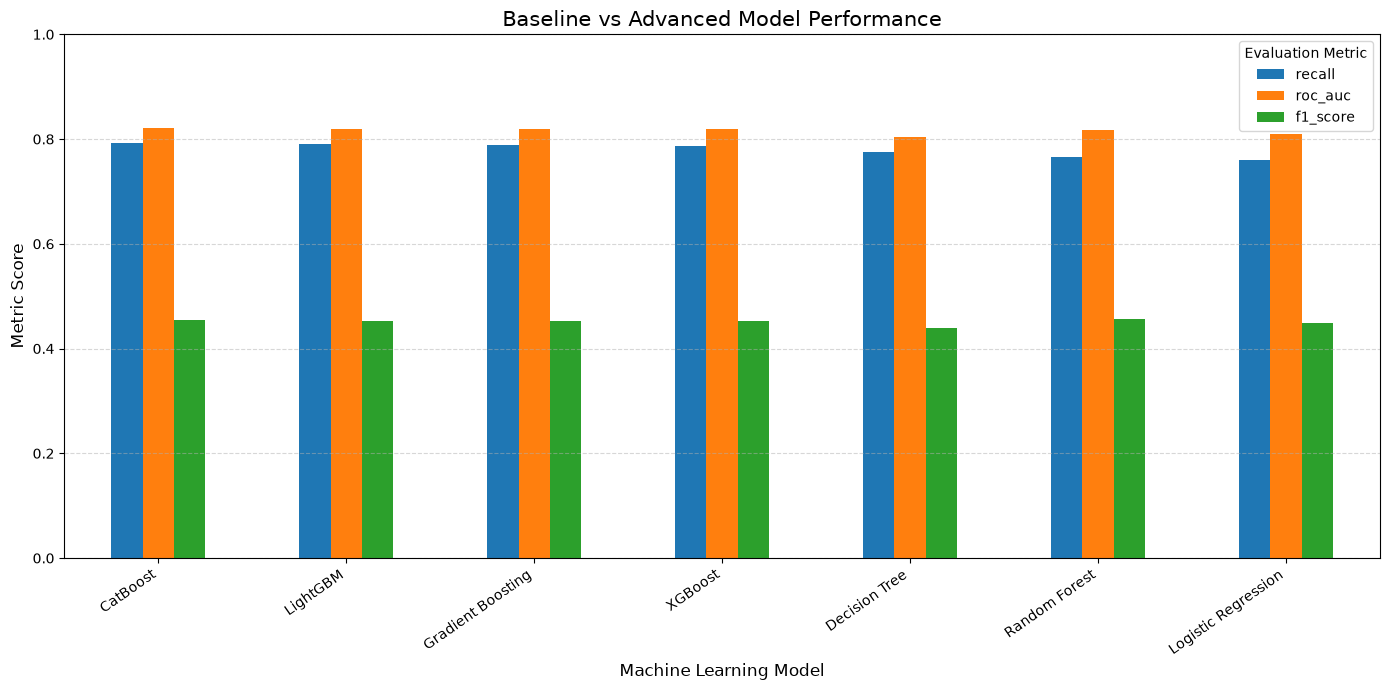

Model comparison plot saved successfully.
File location: /Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/reports/figures/day4/all_model_metric_comparison.png


In [22]:
# Select model names and important evaluation metrics
plot_data = all_results.set_index(
    "model"
)[
    [
        "recall",
        "roc_auc",
        "f1_score"
    ]
]


# Create a grouped bar chart
ax = plot_data.plot(
    kind="bar",
    figsize=(14, 7)
)


# Add chart labels and title
ax.set_title(
    "Baseline vs Advanced Model Performance",
    fontsize=15
)

ax.set_xlabel(
    "Machine Learning Model",
    fontsize=12
)

ax.set_ylabel(
    "Metric Score",
    fontsize=12
)

# All metrics range from 0 to 1
ax.set_ylim(0, 1)

# Rotate model names for readability
plt.xticks(
    rotation=35,
    ha="right"
)

# Display metric names
plt.legend(
    title="Evaluation Metric"
)

# Add horizontal grid lines
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()


# Define the output path
comparison_figure_path = (
    FIGURES_DIR
    / "all_model_metric_comparison.png"
)


# Save the figure
plt.savefig(
    comparison_figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Confirm that the figure was saved
if comparison_figure_path.exists():
    print("Model comparison plot saved successfully.")
    print("File location:", comparison_figure_path)
else:
    raise FileNotFoundError(
        "The model comparison plot was not saved."
    )

In [23]:
# Select the most important comparison columns
candidate_columns = [
    "model",
    "model_group",
    "recall",
    "roc_auc",
    "f1_score",
    "precision",
    "accuracy",
    "training_time_seconds"
]


# Create the candidate comparison table
candidate_results = all_results[
    candidate_columns
].copy()


# Rank models using the main healthcare metrics
candidate_results["recall_rank"] = (
    candidate_results["recall"]
    .rank(
        method="min",
        ascending=False
    )
)

candidate_results["roc_auc_rank"] = (
    candidate_results["roc_auc"]
    .rank(
        method="min",
        ascending=False
    )
)

candidate_results["f1_rank"] = (
    candidate_results["f1_score"]
    .rank(
        method="min",
        ascending=False
    )
)


# Create a simple combined ranking score
candidate_results["combined_rank_score"] = (
    candidate_results["recall_rank"]
    + candidate_results["roc_auc_rank"]
    + candidate_results["f1_rank"]
)


# Lower combined rank score means better overall ranking
candidate_results = candidate_results.sort_values(
    by=[
        "combined_rank_score",
        "recall",
        "roc_auc"
    ],
    ascending=[
        True,
        False,
        False
    ]
).reset_index(drop=True)


print("Candidate models for Day 5 hyperparameter tuning:")

display(candidate_results)

Candidate models for Day 5 hyperparameter tuning:


,model,model_group,recall,roc_auc,f1_score,precision,accuracy,training_time_seconds,recall_rank,roc_auc_rank,f1_rank,combined_rank_score
0,CatBoost,Advanced,0.791851,0.820630,0.454735,0.318949,0.709576,2.120072,1.0,1.0,2.0,4.0
1,LightGBM,Advanced,0.791281,0.819716,0.453388,0.317716,0.708204,1.863033,2.0,2.0,3.0,7.0
2,XGBoost,Advanced,0.787292,0.819603,0.453062,0.318043,0.709293,0.733714,4.0,3.0,4.0,11.0
3,Gradient Boosting,Advanced,0.789144,0.818931,0.452755,0.317439,0.708247,10.680449,3.0,4.0,5.0,12.0
4,Random Forest,Baseline,0.765066,0.816797,0.457313,0.326127,0.722301,NaN,6.0,5.0,1.0,12.0
5,Decision Tree,Baseline,0.775609,0.804641,0.438484,0.305637,0.696198,NaN,5.0,7.0,7.0,19.0
6,Logistic Regression,Baseline,0.759652,0.810580,0.448350,0.318025,0.714108,NaN,7.0,6.0,6.0,19.0


In [28]:

required_day4_files = {
    "Advanced model results": ADVANCED_RESULTS_PATH,
    "Complete model comparison": ALL_RESULTS_PATH,
    "Model comparison figure": comparison_figure_path
}


print("=" * 70)
print("DAY 4 OUTPUT VERIFICATION")
print("=" * 70)

all_files_exist = True

for file_name, file_path in required_day4_files.items():

    if file_path.exists():
        print(f"{file_name}")
        print(f"   {file_path}")

    else:
        print(f"{file_name} is missing")
        print(f"   Expected location: {file_path}")

        all_files_exist = False



advanced_model_count = len(advanced_results)
total_model_count = len(all_results)

print("\n" + "-" * 70)
print("MODEL COUNT VERIFICATION")
print("-" * 70)

print(
    f"Advanced models completed: "
    f"{advanced_model_count}/4"
)

print(
    f"Total models compared: "
    f"{total_model_count}/7"
)


top_candidates = candidate_results.head(3).copy()

print("\n" + "-" * 70)
print("TOP CANDIDATES FOR DAY 5 TUNING")
print("-" * 70)

display(
    top_candidates[
        [
            "model",
            "model_group",
            "recall",
            "roc_auc",
            "f1_score",
            "precision",
            "accuracy",
            "combined_rank_score"
        ]
    ]
)

current_leader = top_candidates.iloc[0]

print("Current leading candidate:")
print(f"Model: {current_leader['model']}")
print(f"Recall: {current_leader['recall']:.4f}")
print(f"ROC-AUC: {current_leader['roc_auc']:.4f}")
print(f"F1-score: {current_leader['f1_score']:.4f}")
print(f"Precision: {current_leader['precision']:.4f}")



DAY 4 OUTPUT VERIFICATION
Advanced model results
   /Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/reports/advanced_model_results.csv
Complete model comparison
   /Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/reports/all_model_comparison.csv
Model comparison figure
   /Users/balavardhan/Desktop/AI Engineering/diabetes-risk-prediction-mlops/reports/figures/day4/all_model_metric_comparison.png

----------------------------------------------------------------------
MODEL COUNT VERIFICATION
----------------------------------------------------------------------
Advanced models completed: 4/4
Total models compared: 7/7

----------------------------------------------------------------------
TOP CANDIDATES FOR DAY 5 TUNING
----------------------------------------------------------------------


,model,model_group,recall,roc_auc,f1_score,precision,accuracy,combined_rank_score
0,CatBoost,Advanced,0.791851,0.820630,0.454735,0.318949,0.709576,4.0
1,LightGBM,Advanced,0.791281,0.819716,0.453388,0.317716,0.708204,7.0
2,XGBoost,Advanced,0.787292,0.819603,0.453062,0.318043,0.709293,11.0


Current leading candidate:
Model: CatBoost
Recall: 0.7919
ROC-AUC: 0.8206
F1-score: 0.4547
Precision: 0.3189
